In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))

import pandas as pd
from src.data_loader import load_datasets, get_train_test_split

print('Loading datasets...')
lob_df, articles_df = load_datasets()
train_df, test_df = get_train_test_split()

print(f'Total articles: {len(articles_df)}')
print(f'Train set: {len(train_df)}')
print(f'Test set:  {len(test_df)}')
print(f'Unique LOBs in test: {test_df["lob_code_str"].nunique()}')
print('\nClass distribution (top 10 LOBs in test):')
print(test_df['lob_code_str'].value_counts().head(10))

Loading datasets...
Total articles: 20499
Train set: 17426
Test set:  3073
Unique LOBs in test: 99

Class distribution (top 10 LOBs in test):
lob_code_str
1002     301
3004     272
4009     232
2002     197
17001    145
3014     120
24001     88
6002      78
2001      74
1001      74
Name: count, dtype: int64


In [2]:
def compute_metrics(results_df: pd.DataFrame) -> dict:
    """
    results_df columns:
      article_code, true_lob, pred_lob_1, pred_lobs_top3 (list),
      pred_inventory_1, true_inventory, confidence_1, correct_top1, correct_top3
    """
    top1 = results_df['correct_top1'].mean()
    top3 = results_df['correct_top3'].mean()

    inventory_mask = results_df['correct_top1']
    inv_acc = (
        results_df.loc[inventory_mask, 'pred_inventory_1'] ==
        results_df.loc[inventory_mask, 'true_inventory']
    ).mean() if inventory_mask.sum() > 0 else float('nan')

    mean_conf_correct = results_df.loc[results_df['correct_top1'], 'confidence_1'].mean()
    mean_conf_wrong = results_df.loc[~results_df['correct_top1'], 'confidence_1'].mean()

    return {
        'top1_accuracy': round(top1, 4),
        'top3_accuracy': round(top3, 4),
        'inventory_accuracy_when_top1_correct': round(inv_acc, 4) if inv_acc == inv_acc else None,
        'mean_confidence_correct': round(mean_conf_correct, 4) if mean_conf_correct == mean_conf_correct else None,
        'mean_confidence_incorrect': round(mean_conf_wrong, 4) if mean_conf_wrong == mean_conf_wrong else None,
    }

In [3]:
from tqdm import tqdm
from src.graph import classify_article
from src.vectorstore_setup import initialize_vectorstore
from src.data_loader import load_datasets, get_train_test_split

# Initialize vectorstore (skips if already built)
lob_df, _ = load_datasets()
train_df, test_df = get_train_test_split()
print(len(train_df), len(test_df))
initialize_vectorstore(train_df, lob_df)

SAMPLE_SIZE = 100
SAVE_EVERY = 10
RESULTS_PATH = 'eval_results.csv'

sample = test_df.sample(n=min(SAMPLE_SIZE, len(test_df)), random_state=42)

records = []
for i, (_, row) in enumerate(tqdm(sample.iterrows(), total=len(sample))):
    code = row['codice_articolo']
    true_lob = row['lob_code_str']
    true_inv = row['inventario']

    try:
        result = classify_article(code)
        print(result)
        suggestions = result.get('suggestions', [])

        pred_lob_1 = suggestions[0]['lob_code'] if suggestions else None
        pred_inv_1 = suggestions[0]['inventory'] if suggestions else None
        confidence_1 = suggestions[0]['confidence'] if suggestions else 0.0
        pred_lobs_top3 = [s['lob_code'] for s in suggestions[:3]]
    except Exception as exc:
        print(exc)
        pred_lob_1, pred_inv_1, confidence_1, pred_lobs_top3 = None, None, 0.0, []

    records.append({
        'article_code': code,
        'true_lob': true_lob,
        'true_inventory': true_inv,
        'pred_lob_1': pred_lob_1,
        'pred_inventory_1': pred_inv_1,
        'confidence_1': confidence_1,
        'pred_lobs_top3': pred_lobs_top3,
        'correct_top1': pred_lob_1 == true_lob,
        'correct_top3': true_lob in pred_lobs_top3,
    })

    if (i + 1) % SAVE_EVERY == 0:
        pd.DataFrame(records).to_csv(RESULTS_PATH, index=False)
        print(f'Saved {i+1} results to {RESULTS_PATH}')

results_df = pd.DataFrame(records)
results_df.to_csv(RESULTS_PATH, index=False)
print(f'Evaluation complete. {len(results_df)} articles evaluated.')

17426 3073


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vectorstore already populated — skipping embedding.


  0%|          | 0/100 [00:00<?, ?it/s]

...

[timing] rag_classification: 36.75s

{'article_code': 'C9200L-48T-4G-E', 'article_description': 'Catalyst 9200L 48-port data, 4 x 1G, Network Essentials', 'existing_lob': '2002 - APPARATI CISCO LAN', 'existing_inventory': 'Inventario', 'web_enrichment': 'Hardware. Articolo durevole/capitale. Prodotto autonomo. Ciclo di vita 5 anni, ammortamento categoria IT Equipment.', 'suggestions': [{'rank': 1, 'lob_code': '2002', 'lob_name': 'APPARATI CISCO', 'inventory': 'Inventario', 'explanation': "L'articolo è un switch Cisco Catalyst 9200L, simile a prodotti precedentemente classificati nel LOB 2002 (es. Catalyst 9300L). È hardware durevole con ammortamento IT Equipment, quindi rientra in inventario.", 'confidence': 0.975}, {'rank': 2, 'lob_code': '4002', 'lob_name': 'ALTRO MATERIALE', 'inventory': 'Inventario', 'explanation': "Non esiste un LOB specifico per Cisco, ma il prodotto è hardware durevole e non rientra in categorie cloud/installazione. La classificazione 'Altro Materiale' è la più 

 99%|█████████▉| 99/100 [2:38:25<01:21, 81.19s/it]

[timing] rag_classification: 69.94s

{'article_code': 'HPE-EOSL-96-ISS', 'article_description': '570103-421', 'existing_lob': '3004 - CLOUD VARIE HW', 'existing_inventory': 'Non in inventario', 'web_enrichment': 'Hardware, consumabile, componente, ciclo breve, ammortamento consumabile.  \nCategoria: Componente accessorio, ammortamento lineare su 2-3 anni.', 'suggestions': [{'rank': 1, 'lob_code': '2005', 'lob_name': 'APPARATI HP', 'inventory': 'Inventario', 'explanation': "Il prodotto è un componente consumabile HPE, coerente con il LOB 2005 (APPARATI HP) e la descrizione di prodotti simili in inventario. L'ammortamento lineare su 2-3 anni è tipico di beni ammortizzabili in inventario.", 'confidence': 0.425}, {'rank': 2, 'lob_code': '4002', 'lob_name': 'ALTRO MATERIALE', 'inventory': 'Non in inventario', 'explanation': "Il prodotto è un consumabile con ciclo breve, che richiede ammortamento lineare su 2-3 anni, tipico di beni non in inventario. La categoria 'ALTRO MATERIALE' include co

100%|██████████| 100/100 [2:39:58<00:00, 95.98s/it]

[timing] rag_classification: 63.43s

{'article_code': 'FTS:HP08NS20SE1379', 'article_description': 'OS,9x5,NBD Rt s/n YMBQ004361', 'existing_lob': '3004 - CLOUD VARIE HW', 'existing_inventory': 'Inventario', 'web_enrichment': 'Servizio, articolo fungibile, componente/accessorio, ciclo di vita 3 anni, ammortamento categoria "servizi".', 'suggestions': [{'rank': 1, 'lob_code': '3004', 'lob_name': 'STORAGE HITACHI', 'inventory': 'Non in inventario', 'explanation': "Il prodotto è descritto come servizio con ammortamento categoria 'servizi', coerente con la classificazione di articoli simili come 'Rinnovo Fujitsu OS' (similarity: 0.632). I servizi non sono inclusi in inventario.", 'confidence': 0.7775}, {'rank': 2, 'lob_code': '3036', 'lob_name': 'RINNOVO STORAGE HITACHI', 'inventory': 'Non in inventario', 'explanation': "La descrizione 'OS,9x5,NBD Rt s/n' suggerisce un rinnovo di software/storage, conforme a precedenti classificazioni di articoli simili (similarity: 0.51). I servizi di rin

In [4]:
metrics = compute_metrics(results_df)
summary = pd.DataFrame([metrics]).T
summary.columns = ['value']
print('=== EVALUATION SUMMARY ===')
print(summary.to_string())

=== EVALUATION SUMMARY ===
                                       value
top1_accuracy                         0.2000
top3_accuracy                         0.2700
inventory_accuracy_when_top1_correct  0.8000
mean_confidence_correct               0.8981
mean_confidence_incorrect             0.5298


Matplotlib is building the font cache; this may take a moment.


Top 10 confused LOB pairs (true → predicted):
pair
3004 → 4002     5
1002 → 4002     5
4009 → 4002     4
1006 → 4002     3
6003 → 6012     2
17001 → 4002    2
4008 → 2002     2
3009 → 4002     1
6002 → 6001     1
6009 → 2005     1

--- Example incorrect classifications ---
Article: OS01137233
  True LOB: 6003, Predicted: 6012, Confidence: 0.925
Article: SP-PSU-4A
  True LOB: 24001, Predicted: 6004, Confidence: 0.734
Article: L-SX-SERIES-PAK
  True LOB: 4008, Predicted: 3031, Confidence: 0.911
Article: A-MST-CVI-RMS-ENT
  True LOB: 4015, Predicted: 4008, Confidence: 0.877
Article: AR8603A
  True LOB: 17001, Predicted: 2002, Confidence: 0.610


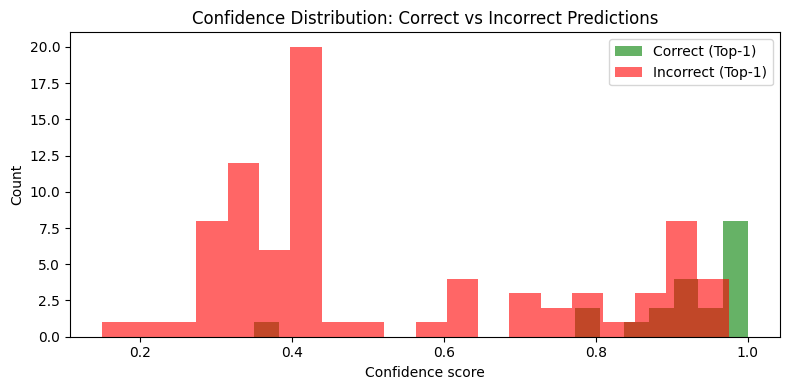

Saved: confidence_distribution.png


In [5]:
import matplotlib.pyplot as plt

# Top 10 confusion pairs
error_df = results_df[~results_df['correct_top1']].copy()
if len(error_df) > 0:
    error_df['pair'] = error_df['true_lob'] + ' → ' + error_df['pred_lob_1'].fillna('None')
    top_confusions = error_df['pair'].value_counts().head(10)
    print('Top 10 confused LOB pairs (true → predicted):')
    print(top_confusions.to_string())
else:
    print('No errors to analyze.')

# Example incorrect classifications
print('\n--- Example incorrect classifications ---')
for _, row in error_df.head(5).iterrows():
    print(f"Article: {row['article_code']}")
    print(f"  True LOB: {row['true_lob']}, Predicted: {row['pred_lob_1']}, Confidence: {row['confidence_1']:.3f}")

# Confidence distribution histogram
fig, ax = plt.subplots(figsize=(8, 4))
correct_conf = results_df.loc[results_df['correct_top1'], 'confidence_1']
wrong_conf = results_df.loc[~results_df['correct_top1'], 'confidence_1']
ax.hist(correct_conf, bins=20, alpha=0.6, label='Correct (Top-1)', color='green')
ax.hist(wrong_conf, bins=20, alpha=0.6, label='Incorrect (Top-1)', color='red')
ax.set_xlabel('Confidence score')
ax.set_ylabel('Count')
ax.set_title('Confidence Distribution: Correct vs Incorrect Predictions')
ax.legend()
plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=100)
plt.show()
print('Saved: confidence_distribution.png')

In [7]:
lob_stats = (
    results_df.groupby('true_lob')
    .agg(
        n_samples=('correct_top1', 'count'),
        top1_acc=('correct_top1', 'mean'),
        top3_acc=('correct_top3', 'mean'),
    )
    .reset_index()
    .sort_values('top1_acc')
)

# Join LOB names
lob_names = lob_df[['LOB Code', 'Name']].rename(columns={'LOB Code': 'true_lob'})
lob_names['true_lob'] = lob_names['true_lob'].astype(str)
lob_stats = lob_stats.merge(lob_names, on='true_lob', how='left')

print('Per-LOB accuracy (worst first):')
print(lob_stats[['true_lob', 'Name', 'n_samples', 'top1_acc', 'top3_acc']].to_string(index=False))

Per-LOB accuracy (worst first):
true_lob                            Name  n_samples  top1_acc  top3_acc
    1001              CABLAGGI COMMSCOPE          2  0.000000  0.500000
    6009             FORCEPOINT SECURITY          1  0.000000  0.000000
    6003       TREND MICRO PRIMA VENDITA          2  0.000000  0.000000
    6002             CHECKPOINT SECURITY          3  0.000000  0.000000
    4015    CISCO COLLABORATION A CANONE          1  0.000000  0.000000
    4008     CISCO VIDEOCONFERENZA/BOARD          4  0.000000  0.000000
    4007     INSTALLAZIONE COLLABORATION          2  0.000000  0.000000
    4005                ROUTER TELEFONIA          1  0.000000  0.000000
    4004              TELEFONIA SOFTWARE          3  0.000000  0.000000
    3039                          RUBRIK          2  0.000000  0.000000
    3035                 STORAGE HITACHI          1  0.000000  0.000000
    3014                SOLUZIONE NETAPP          5  0.000000  0.000000
   99001                        

In [10]:
from src.state import AgentState
from src.nodes.rag_classification import rag_classification_node
from src.data_loader import load_datasets


def classify_article_no_web(article_code: str) -> dict:
    """Classification pipeline without web enrichment (Node 2 skipped)."""
    _, articles_df = load_datasets()
    from src.data_loader import get_article_info
    article_info = get_article_info(article_code, articles_df)

    if article_info is None:
        return {'article_code': article_code, 'suggestions': [], 'error': 'not found'}

    state: AgentState = {
        'article_code': article_code,
        'article_info': article_info,
        'web_enrichment': '',
        'retrieval_results': [],
        'classification': [],
        'error': None,
    }

    rag_result = rag_classification_node(state)
    return {
        'article_code': article_code,
        'suggestions': rag_result.get('classification', []),
        'error': rag_result.get('error'),
    }


# Run no-web evaluation on same sample
records_no_web = []
for i, (_, row) in enumerate(tqdm(sample.iterrows(), total=len(sample))):
    code = row['codice_articolo']
    true_lob = row['lob_code_str']
    true_inv = row['inventario']

    try:
        result = classify_article_no_web(code)
        suggestions = result.get('suggestions', [])
        pred_lob_1 = suggestions[0]['lob_code'] if suggestions else None
        pred_inv_1 = suggestions[0]['inventory'] if suggestions else None
        confidence_1 = suggestions[0]['confidence'] if suggestions else 0.0
        pred_lobs_top3 = [s['lob_code'] for s in suggestions[:3]]
    except Exception:
        pred_lob_1, pred_inv_1, confidence_1, pred_lobs_top3 = None, None, 0.0, []

    records_no_web.append({
        'article_code': code,
        'true_lob': true_lob,
        'true_inventory': true_inv,
        'pred_lob_1': pred_lob_1,
        'pred_inventory_1': pred_inv_1,
        'confidence_1': confidence_1,
        'pred_lobs_top3': pred_lobs_top3,
        'correct_top1': pred_lob_1 == true_lob,
        'correct_top3': true_lob in pred_lobs_top3,
    })

results_no_web_df = pd.DataFrame(records_no_web)
metrics_no_web = compute_metrics(results_no_web_df)

print('=== WITH WEB ENRICHMENT ===')
for k, v in metrics.items():
    print(f'  {k}: {v}')

print('\n=== WITHOUT WEB ENRICHMENT ===')
for k, v in metrics_no_web.items():
    print(f'  {k}: {v}')

100%|██████████| 100/100 [1:37:21<00:00, 58.42s/it]

=== WITH WEB ENRICHMENT ===
  top1_accuracy: 0.2
  top3_accuracy: 0.27
  inventory_accuracy_when_top1_correct: 0.8
  mean_confidence_correct: 0.8981
  mean_confidence_incorrect: 0.5298

=== WITHOUT WEB ENRICHMENT ===
  top1_accuracy: 0.33
  top3_accuracy: 0.47
  inventory_accuracy_when_top1_correct: 0.9091
  mean_confidence_correct: 0.9139
  mean_confidence_incorrect: 0.5037
